In [ ]:
from dataclasses import dataclass
#from typing import List

@dataclass
class PointGPS:
    time: str
    latitude: float
    longitude: float
    altitude: float
    distance: float
    heartRate: int
    speed: float
    runCadence: int
    watts: int


@dataclass
class Lap:
    start_time: str
    total_time: float
    distance: float
    max_speed: float
    calories: int
    avg_hr: int
    max_hr: int
    intensity: str
    trigger: str
    points: list[PointGPS]

@dataclass
class date:
    year : float
    month : float
    week : float
    day : float
    
@dataclass
class Activite:
    sport: str
    id: str
    laps: list[Lap]

In [3]:
from pathlib import Path
import json

# Utilitaire pour désérialiser un fichier JSON en Activite
def load_activity(json_path: Path) -> Activite:
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    laps = []
    for lap_data in data["laps"]:
        points = [PointGPS(**pt) for pt in lap_data["points"]]
        laps.append(Lap(**{**lap_data, "points": points}))

    return Activite(**{**data, "laps": laps})

In [127]:
#pour avoir objets Python bien typés (Activite, Lap, PointGPS) au lieu de dictionnaires JSON bruts.

import os
# Charge toutes les activités
def load_all_activities(folder_path: str) -> list[Activite]:
    activities = []
    for filename in os.listdir(folder_path):
        if filename.endswith(".json") and filename != "index.json":
            full_path = os.path.join(folder_path, filename)
            activities.append(load_activity(full_path))
    return activities


In [5]:
import os
print("Répertoire courant :", os.getcwd())
 

Répertoire courant : c:\Users\shumb\OneDrive\Documents\Visual Studio Code\Running Datas


In [6]:

import os

# 📁 Le chemin depuis le dossier Running Datas
folder_path = "site/activities_json"

# 🔍 Vérification
print("Répertoire courant :", os.getcwd())
print("Fichiers trouvés :", os.listdir(folder_path))

# ✅ Chargement
all_activities = load_all_activities(folder_path)


Répertoire courant : c:\Users\shumb\OneDrive\Documents\Visual Studio Code\Running Datas
Fichiers trouvés : ['activity_17482399352.json', 'activity_17490289008.json', 'activity_17507109341.json', 'activity_17512456424.json', 'activity_17522554619.json', 'activity_17535799744.json', 'activity_17550087476.json', 'activity_17556631216.json', 'activity_17556631939.json', 'activity_17649066143.json', 'activity_17665683882.json', 'activity_17686792876.json', 'activity_17700789297.json', 'activity_17715922870.json', 'activity_19112217557.json', 'Biking-FR955-2025-07-13.json', 'index.json', 'shumbert23@gmail.com_283009237701.json', 'shumbert23@gmail.com_348916796220.json']


In [7]:
def format_time(total_seconds: float) -> str:
    # On arrondit à l'entier le plus proche
    total_seconds = int(round(total_seconds))
    
    hours = total_seconds // 3600
    minutes = (total_seconds % 3600) // 60
    seconds = total_seconds % 60

    if hours > 0:
        return f"{hours:02}:{minutes:02}:{seconds:02}"
    else:
        return f"{minutes:02}:{seconds:02}"


# Exemple avec tes données
laps = [355.897, 120.5, 65.2]  # en secondes
total = sum(laps)

print("Temps total :", format_time(total))


Temps total : 09:02


In [23]:
from datetime import datetime

def Strg_to_Date(StartTime: str):
    # Conversion de la chaîne en objet datetime
    dt = datetime.strptime(StartTime, "%Y-%m-%dT%H:%M:%S.%fZ")  #"2025-07-13T17:21:04.000Z"
    
    year = dt.year
    month = dt.month
    week = dt.isocalendar()[1]  # Numéro de la semaine
    day = dt.day
    
    return {
        "year": year,
        "month": month,
        "week": week,
        "day": day
    }

# Exemple d'utilisation
Date = Strg_to_Date("2025-07-13T17:21:04.000Z")
print(Date)


{'year': 2025, 'month': 7, 'week': 28, 'day': 13}


In [226]:
#création de stats à partir de all_activities 
# Fonction pour initialiser un dictionnaire de stats
def default_stat():
    return {"nb": 0, "dist": 0.0, "time": 0.0, "elevation": 0.0}

stats = {}

for act in all_activities:
    
    sport = act.sport
    date = Strg_to_Date(act.laps[0].start_time)
    year = date["year"]
    month = date["month"]
    week = date["week"]
    day = date["day"]

    total_dist = sum(lap.distance for lap in act.laps) / 1000
    total_time = sum(lap.total_time for lap in act.laps)
   
    print(f"{act.id} - {act.sport} - {day}/{month}/{year}: {format_time(total_time)}")  #ajouter la date à partir de act.start_time

    # Création des clés si elles n'existent pas
    if sport not in stats:
        stats[sport] = {}
    if year not in stats[sport]:
        stats[sport][year] = {
            "year": default_stat(),
            "months": {},
            "weeks": {}
        }
    if month not in stats[sport][year]["months"]:
        stats[sport][year]["months"][month] = default_stat()
    if week not in stats[sport][year]["weeks"]:
        stats[sport][year]["weeks"][week] = default_stat()

    # Agrégation
    stats[sport][year]["year"]["nb"] += 1
    stats[sport][year]["year"]["dist"] += total_dist
    stats[sport][year]["year"]["time"] += total_time
    

    stats[sport][year]["months"][month]["nb"] += 1
    stats[sport][year]["months"][month]["dist"] += total_dist
    stats[sport][year]["months"][month]["time"] += total_time
    

    stats[sport][year]["weeks"][week]["nb"] += 1
    stats[sport][year]["weeks"][week]["dist"] += total_dist
    stats[sport][year]["weeks"][week]["time"] += total_time
    
    


activity_17482399352 - Running - 7/11/2024: 49:05
activity_17490289008 - Running - 8/11/2024: 01:05:03
activity_17507109341 - Running - 10/11/2024: 14:58
activity_17512456424 - Other - 11/11/2024: 01:30:34
activity_17522554619 - Running - 12/11/2024: 54:43
activity_17535799744 - Running - 14/11/2024: 31:33
activity_17550087476 - Running - 16/11/2024: 20:16
activity_17556631216 - Running - 17/11/2024: 23:07
activity_17556631939 - Running - 17/11/2024: 37:08
activity_17649066143 - Running - 29/11/2024: 44:29
activity_17665683882 - Running - 1/12/2024: 27:11
activity_17686792876 - Running - 4/12/2024: 52:19
activity_17700789297 - Running - 6/12/2024: 57:55
activity_17715922870 - Running - 8/12/2024: 01:40:48
activity_19112217557 - Biking - 13/5/2025: 50:19
Biking-FR955-2025-07-13 - Biking - 13/7/2025: 01:44:28
shumbert23@gmail.com_283009237701 - Running - 4/10/2024: 01:09:56
shumbert23@gmail.com_348916796220 - Biking - 13/7/2025: 01:44:28


In [128]:
#-------Traitement de stats-------

# Totaux globaux toutes activités
nb_all_time = 0
distance_all_time = 0
time_all_time = 0

for sport, years in stats.items():
    print(f"\n=== {sport} ===")

    # Totaux par sport
    sport_nb_all_time = 0
    sport_distance_all_time = 0
    sport_time_all_time = 0

    for year, data in years.items():
        sport_nb_all_time += data["year"]["nb"]
        sport_distance_all_time += data["year"]["dist"]
        sport_time_all_time += data["year"]["time"]

    # Affichage all time par sport
    print(f"all time : {sport_nb_all_time} activités, "
          f"Distance all time : {sport_distance_all_time:.2f} km, "
          f"Temps all time : {format_time(sport_time_all_time)}")

    # Détails par année
    for year, data in years.items():
        nb = data["year"]["nb"]
        dist = data["year"]["dist"]
        time = data["year"]["time"]

        print(f"    Année {year} : {nb} activités, {dist:.2f} km, durée : {format_time(time)}")

        # Détails par mois
        for month, mdata in sorted(data["months"].items()):
            nb_m = mdata["nb"]
            dist_m = mdata["dist"]
            time_m = mdata["time"]
            print(f"\tmois {month} : {nb_m} activités, {dist_m:.2f} km, durée : {format_time(time_m)}")

    # Ajout aux totaux globaux
    nb_all_time += sport_nb_all_time
    distance_all_time += sport_distance_all_time
    time_all_time += sport_time_all_time

# Totaux toutes activités
print(f"\n=== Toutes activités ===")
print(f"all time : {nb_all_time} activités, "
      f"Distance all time : {distance_all_time:.2f} km, "
      f"Temps all time : {format_time(time_all_time)}")



=== Running ===
all time : 14 activités, Distance all time : 119.20 km, Temps all time : 10:48:29
    Année 2024 : 14 activités, 119.20 km, durée : 10:48:29
	mois 10 : 1 activités, 13.03 km, durée : 01:09:56
	mois 11 : 9 activités, 65.24 km, durée : 05:40:21
	mois 12 : 4 activités, 40.93 km, durée : 03:58:12

=== Other ===
all time : 1 activités, Distance all time : 5.74 km, Temps all time : 01:30:34
    Année 2024 : 1 activités, 5.74 km, durée : 01:30:34
	mois 11 : 1 activités, 5.74 km, durée : 01:30:34

=== Biking ===
all time : 3 activités, Distance all time : 119.16 km, Temps all time : 04:19:14
    Année 2025 : 3 activités, 119.16 km, durée : 04:19:14
	mois 5 : 1 activités, 26.78 km, durée : 50:19
	mois 7 : 2 activités, 92.38 km, durée : 03:28:55

=== Toutes activités ===
all time : 18 activités, Distance all time : 244.10 km, Temps all time : 16:38:17


In [225]:
import json

STATS_PATH = "stats.json"

#-------Traitement de stats-------

# Totaux globaux toutes activités
nb_all_time = 0
distance_all_time = 0
time_all_time = 0

# Dictionnaire qui servira à stocker toutes les infos pour le JSON
stats_summary = {}

for sport, years in stats.items():
    print(f"\n=== {sport} ===")

    # Totaux par sport
    sport_nb_all_time = 0
    sport_distance_all_time = 0
    sport_time_all_time = 0

    sport_data = {"years": {}}  # pour le JSON

    for year, data in years.items():
        sport_nb_all_time += data["year"]["nb"]
        sport_distance_all_time += data["year"]["dist"]
        sport_time_all_time += data["year"]["time"]

        # Sauvegarde dans le dictionnaire
        sport_data["years"][year] = {
            "year": {
                "nb": data["year"]["nb"],
                "dist": data["year"]["dist"],
                "time": data["year"]["time"]
            },
            "months": {}
        }

        # Détails par mois
        for month, mdata in sorted(data["months"].items()):
            sport_data["years"][year]["months"][month] = {
                "nb": mdata["nb"],
                "dist": mdata["dist"],
                "time": mdata["time"]
            }

    # Affichage all time par sport
    print(f"all time : {sport_nb_all_time} activités, "
          f"Distance all time : {sport_distance_all_time:.2f} km, "
          f"Temps all time : {format_time(sport_time_all_time)}")

    # Ajout au résumé JSON
    sport_data["all_time"] = {
        "nb": sport_nb_all_time,
        "dist": sport_distance_all_time,
        "time": sport_time_all_time
    }
    stats_summary[sport] = sport_data

    # Ajout aux totaux globaux
    nb_all_time += sport_nb_all_time
    distance_all_time += sport_distance_all_time
    time_all_time += sport_time_all_time

# Totaux toutes activités
print(f"\n=== Toutes activités ===")
print(f"all time : {nb_all_time} activités, "
      f"Distance all time : {distance_all_time:.2f} km, "
      f"Temps all time : {format_time(time_all_time)}")

# Ajout global au JSON
stats_summary["All"] = {
    "all_time": {
        "nb": nb_all_time,
        "dist": distance_all_time,
        "time": time_all_time
    }
}

# Sauvegarde dans le fichier stats.json
with open(STATS_PATH, "w", encoding="utf-8") as f:
    json.dump(stats_summary, f, indent=4, ensure_ascii=False)
print(f"\n📁 Statistiques enregistrées dans {STATS_PATH}")



=== Running ===
all time : 14 activités, Distance all time : 119.20 km, Temps all time : 10:48:29

=== Other ===
all time : 1 activités, Distance all time : 5.74 km, Temps all time : 01:30:34

=== Biking ===
all time : 3 activités, Distance all time : 119.16 km, Temps all time : 04:19:14

=== Toutes activités ===
all time : 18 activités, Distance all time : 244.10 km, Temps all time : 16:38:17

📁 Statistiques enregistrées dans stats.json


In [ ]:
from datetime import datetime

def convert_time_to_seconds(points):
    """
    Prend une liste de points ayant un attribut 'time' au format ISO 8601 (ex: '2024-11-07T17:34:47.000Z')
    et ajoute un champ 'elapsed' = temps écoulé en secondes depuis le début.
    Retourne la durée totale (en secondes).
    """

    # Format des timestamps ISO
    fmt = "%Y-%m-%dT%H:%M:%S.%fZ"

    # Récupérer le temps du premier point
    if not points:
        return 0

    start_time = datetime.strptime(points[0].time, fmt)

    for point in points:
        current_time = datetime.strptime(point.time, fmt)
        point.elapsed = (current_time - start_time).total_seconds()

    # Durée totale
    total_duration = points[-1].elapsed
    return total_duration


In [133]:
def parse_time(time_str: str) -> datetime:
    """Convertit une chaîne ISO8601 (ex: '2025-07-13T17:21:04.000Z') en datetime."""
    if not time_str or time_str == "N/A":
        return None
    return datetime.strptime(time_str, "%Y-%m-%dT%H:%M:%S.%fZ")

#retourne  parse_time("2025-07-13T17:21:04.000Z") >>> datetime.datetime(2025, 7, 13, 17, 21, 4)

#-------Exemple------
#t1 = datetime(2025,7,13,23,30,10)
#t2 = datetime(2025,7,14,0,10,15)  # 40 min 5 s après

#delta = t2 - t1                    # timedelta(days=0, seconds=2405)
#print(delta.seconds)               # 2405  (ok ici car < 1 jour)
#print(delta.total_seconds())       # 2405.0

# si > 1 jour
#delta2 = timedelta(days=1, seconds=10)
#print(delta2.seconds)              # 10      (les jours sont séparés)
#print(delta2.total_seconds())      # 86410.0 (ce qui est la vraie durée totale)

#days
#seconds
#microseconds

In [218]:
Running_distances = {200 , 400 , 1000 , 2000, 5000, 10000,15000,20000,21097,30000,42195,50000,100000,150000,200000}
Biking_distances ={1000,2000,5000,10000,20000,30000,40000,50000,75000,100000,125000,150000,200000}

def record_distance(activite, distances):


    records = {}
    all_points = []
    for lap in activite.laps:
        all_points.extend(lap.points)
    if not all_points:
            return {}

    for distance in distances:
        best = float('inf')
        n = len(all_points)
        for i, p1 in enumerate(all_points[:-1]):
            for j in range(i + 1, n):
                if all_points[j].distance - p1.distance >= distance:
                    t1 = parse_time(p1.time)
                    t2 = parse_time(all_points[j].time)
                    dt = (t2 - t1).total_seconds()
                    if dt < best:
                        best = dt
                    break
        if best != float('inf'):
            records[distance] = best
    return records
   #print(f"🏁 Record sur {distance} m : {str_record}")

In [219]:
records = {}

In [220]:
for activite in all_activities:
    # Récupération de la date depuis le 1er lap
    date = Strg_to_Date(activite.laps[0].start_time)
    year = date["year"]
    month = date["month"]
    week = date["week"]
    day = date["day"]
    print(f"{activite.id} - {activite.sport} - {day:02}/{month:02}/{year:04}")
    if activite.sport == "Running":
        new_records = record_distance(activite, Running_distances)
        if activite.sport not in records:
            records[activite.sport] = {}

        for dist, rec in new_records.items():
            best = records.get("Running", {}).get(dist, float('inf'))
            if rec < best:
                records["Running"][dist] = rec
                
    
    if activite.sport == "Biking":
        new_records = record_distance(activite, Biking_distances)
        if activite.sport not in records:
            records[activite.sport] = {}

        for dist, rec in new_records.items():
            best = records.get("Biking", {}).get(dist, float('inf'))
            if rec < best:
                records["Biking"][dist] = rec
                
    print(records)


activity_17482399352 - Running - 07/11/2024
{'Running': {1000: 323.0, 200: 57.0, 5000: 1675.0, 400: 124.0, 2000: 660.0}}
activity_17490289008 - Running - 08/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 80.0, 2000: 525.0, 10000: 3820.0}}
activity_17507109341 - Running - 10/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 80.0, 2000: 525.0, 10000: 3820.0}}
activity_17512456424 - Other - 11/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 80.0, 2000: 525.0, 10000: 3820.0}}
activity_17522554619 - Running - 12/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 77.0, 2000: 525.0, 10000: 3820.0}}
activity_17535799744 - Running - 14/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 77.0, 2000: 525.0, 10000: 3820.0}}
activity_17550087476 - Running - 16/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 77.0, 2000: 507.0, 10000: 3820.0}}
activity_17556631216 - Running - 17/11/2024
{'Running': {1000: 207.0, 2

In [222]:
import json
from datetime import date

RECORDS_PATH = "records.json"

def load_records(path=RECORDS_PATH):
    """Charge le fichier records.json (ou renvoie un dict vide)."""
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        # reconvertir les distances en int
        return {sport: {int(k): v for k, v in distances.items()} for sport, distances in data.items()}
    except FileNotFoundError:
        return {}

def save_records(records, path=RECORDS_PATH):
    """Sauvegarde le dictionnaire dans un fichier JSON."""
    with open(path, "w", encoding="utf-8") as f:
        json.dump(records, f, indent=4, ensure_ascii=False)

def add_record(records, sport, distance, time_s, record_date=None):
    """Ajoute un record si c’est une amélioration."""
    record_date = record_date or date.today().isoformat()
    sport_records = records.setdefault(sport, {})
    dist_records = sport_records.setdefault(distance, [])

    # Vérifie si c’est un meilleur temps
    best_time = min((r["time_s"] for r in dist_records), default=float("inf"))
    if time_s < best_time:
        dist_records.append({"date": record_date, "time_s": time_s})
        print(f"🏆 Nouveau record pour {sport} {distance} m : {time_s}s le {record_date}")
    else:
        print(f"Aucun record battu pour {sport} {distance} m ({time_s}s ≥ {best_time}s)")
    return records


In [223]:
# Chargement du fichier de records
records_history = load_records()

# Dictionnaire pour garder les records du moment (instantané)
records = load_records()

for activite in all_activities:
    # Récupération de la date depuis le 1er lap
    date = Strg_to_Date(activite.laps[0].start_time)
    
    year = date["year"]
    month = date["month"]
    week = date["week"]
    day = date["day"]
    date_str = f"{year:04}-{month:02}-{day:02}"
    print(f"{activite.id} - {activite.sport} - {day:02}/{month:02}/{year:04}")
    
    if activite.sport == "Running":
        new_records = record_distance(activite, Running_distances)
        if activite.sport not in records:
            records[activite.sport] = {}

        for dist, rec in new_records.items():
            best = records.get("Running", {}).get(dist, float('inf'))
            if rec < best:
                records["Running"][dist] = rec
                records_history = add_record(records_history, "Running", dist, rec, date_str)
    
    if activite.sport == "Biking":
        new_records = record_distance(activite, Biking_distances)
        if activite.sport not in records:
            records[activite.sport] = {}

        for dist, rec in new_records.items():
            best = records.get("Biking", {}).get(dist, float('inf'))
            if rec < best:
                records["Biking"][dist] = rec
                records_history = add_record(records_history, "Biking", dist, rec, date_str)
                
    # Sauvegarde finale du fichier JSON mis à jour
    save_records(records_history)
    print(records)


activity_17482399352 - Running - 07/11/2024
🏆 Nouveau record pour Running 1000 m : 323.0s le 2024-11-07
🏆 Nouveau record pour Running 200 m : 57.0s le 2024-11-07
🏆 Nouveau record pour Running 5000 m : 1675.0s le 2024-11-07
🏆 Nouveau record pour Running 400 m : 124.0s le 2024-11-07
🏆 Nouveau record pour Running 2000 m : 660.0s le 2024-11-07
{'Running': {1000: 323.0, 200: 57.0, 5000: 1675.0, 400: 124.0, 2000: 660.0}}
activity_17490289008 - Running - 08/11/2024
🏆 Nouveau record pour Running 1000 m : 207.0s le 2024-11-08
🏆 Nouveau record pour Running 200 m : 27.0s le 2024-11-08
🏆 Nouveau record pour Running 5000 m : 1495.0s le 2024-11-08
🏆 Nouveau record pour Running 400 m : 80.0s le 2024-11-08
🏆 Nouveau record pour Running 2000 m : 525.0s le 2024-11-08
🏆 Nouveau record pour Running 10000 m : 3820.0s le 2024-11-08
{'Running': {1000: 207.0, 200: 27.0, 5000: 1495.0, 400: 80.0, 2000: 525.0, 10000: 3820.0}}
activity_17507109341 - Running - 10/11/2024
{'Running': {1000: 207.0, 200: 27.0, 5000: 

In [221]:
print(records)


# Icônes par type de sport
icons = {
    'Running': '🏃',
    'Biking': '🚴',
    'Other': '⚙️'
}

# Tri personnalisé : Running / Biking / Other / reste
sports_order = ['Running', 'Biking', 'Other']
keys_sorted = sorted(records.keys(), key=lambda k: (sports_order.index(k) if k in sports_order else 999))

for sport in keys_sorted:
    values = records[sport]
    # On ne garde que les sections avec des distances (int comme clés)
    if not all(isinstance(k, (int, float)) for k in values.keys()):
        continue

    print(f"\n{icons.get(sport, '🏁')} {sport}")
    print("-" * (len(sport) + 3))
    for dist, value in sorted(values.items()):
        print(f"{dist:>7} m : {format_time(value)}")



{'Running': {1000: 207.0, 200: 22.0, 5000: 1096.0, 400: 77.0, 2000: 430.0, 10000: 2207.0, 15000: 7214.0}, 'Biking': {20000: 2785.0, 1000: 70.0, 5000: 501.0, 10000: 1041.0, 2000: 154.0, 40000: 5927.0, 30000: 4382.0}}

🏃 Running
----------
    200 m : 00:22
    400 m : 01:17
   1000 m : 03:27
   2000 m : 07:10
   5000 m : 18:16
  10000 m : 36:47
  15000 m : 02:00:14

🚴 Biking
---------
   1000 m : 01:10
   2000 m : 02:34
   5000 m : 08:21
  10000 m : 17:21
  20000 m : 46:25
  30000 m : 01:13:02
  40000 m : 01:38:47


In [ ]:
#plot interactive route 

def plot_interactive_route(latitudes, longitudes):
    # Créer une carte centrée sur le premier point
    map_center = [latitudes[0], longitudes[0]]
    route_map = folium.Map(location=map_center, zoom_start=15)

    # Ajouter des points de passage
    points = list(zip(latitudes, longitudes))
    folium.PolyLine(points, color="blue", weight=5).add_to(route_map)

    # Ajouter des marqueurs pour le début et la fin du trajet
    folium.Marker(points[0], popup="Début", icon=folium.Icon(color="green")).add_to(route_map)
    folium.Marker(points[-1], popup="Fin", icon=folium.Icon(color="red")).add_to(route_map)

    # Sauvegarder la carte dans un fichier HTML
    route_map.save("route_map.html")
    print("Carte enregistrée : route_map.html")


In [ ]:
def plot_heatmap(all_coordinates):
    # Créer une carte centrée sur le premier point
    map_center = all_coordinates[0] if all_coordinates else [0, 0]
    heatmap = folium.Map(location=map_center, zoom_start=13)

    # Ajouter les données de la heatmap
    HeatMap(all_coordinates, radius=10, blur=15, max_zoom=1).add_to(heatmap)

    # Sauvegarder la carte
    heatmap.save("heatmap.html")
    print("Carte enregistrée : heatmap.html")
    return heatmap

# Créer une heatmap
plot_heatmap(all_coordinates)

NameError: name 'all_coordinates' is not defined

In [ ]:
def stats_parcours(points):
    total_distance = sum(p.distance_from_prev for p in points)
    total_time = (points[-1].time - points[0].time).total_seconds()
    vitesse_moy = (total_distance / total_time * 3.6) if total_time > 0 else 0  # en km/h
    print(f"Distance totale : {total_distance:.1f} m")
    print(f"Durée totale    : {total_time/60:.1f} min")
    print(f"Vitesse moyenne : {vitesse_moy:.2f} km/h")

In [ ]:
import matplotlib.pyplot as plt
def plot_vitesse_altitude(points):
    temps = [(p.time - points[0].time).total_seconds() / 60 for p in points]  # en minutes
    vitesses = [p.vitesse_kmh for p in points]
    altitudes = [p.elevation for p in points]

    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.set_xlabel("Temps (minutes)")
    ax1.set_ylabel("Vitesse (km/h)", color="blue")
    ax1.plot(temps, vitesses, color="blue", label="Vitesse")
    ax1.tick_params(axis='y', labelcolor="blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Altitude (m)", color="green")
    ax2.plot(temps, altitudes, color="green", linestyle="--", label="Altitude")
    ax2.tick_params(axis='y', labelcolor="green")

    plt.title("Évolution de la vitesse et de l'altitude")
    plt.grid(True)
    plt.show()



In [ ]:
import matplotlib.pyplot as plt

def plot_data_distance(points, data_name="elevation", ylabel="Altitude (m)", color="green"):
    """
    Trace la courbe d'une donnée (par défaut l'altitude) en fonction de la distance.

    Parameters:
        points: liste de PointGPS
        data_name: nom de l'attribut à tracer (ex: 'elevation', 'vitesse_kmh', 'heartRate')
        ylabel: étiquette de l'axe Y
        color: couleur de la courbe
    """

    distances = [0.0]
    for i in range(1, len(points)):
        d = points[i].distance - points[i-1].distance
        distances.append(distances[-1] + d)

    distances = [d / 1000 for d in distances]  # km

    try:
        values = [getattr(p, data_name) for p in points]
    except AttributeError:
        print(f"Erreur : le champ '{data_name}' n'existe pas dans PointGPS.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(distances, values, color=color)
    plt.xlabel("Distance (km)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} en fonction de la distance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
points = [pt for lap in activity.laps for pt in lap.points]
for pt in points[:10]:
    print(f"altitude={pt.altitude}, distance={pt.distance}, speed={pt.speed}, heartRate={pt.heartRate}")


altitude=0.0, distance=0.0, speed=0, heartRate=72
altitude=0.0, distance=3.29, speed=0, heartRate=72
altitude=0.0, distance=6.86, speed=0, heartRate=72
altitude=0.0, distance=9.6, speed=0, heartRate=72
altitude=0.0, distance=11.7, speed=0, heartRate=72
altitude=0.0, distance=14.45, speed=0, heartRate=72
altitude=0.0, distance=17.61, speed=0, heartRate=72
altitude=0.0, distance=20.72, speed=0, heartRate=73
altitude=0.0, distance=23.89, speed=0, heartRate=74
altitude=0.0, distance=26.7, speed=0, heartRate=75


Activité : 2024-08-23-12-13-46-sport : Running


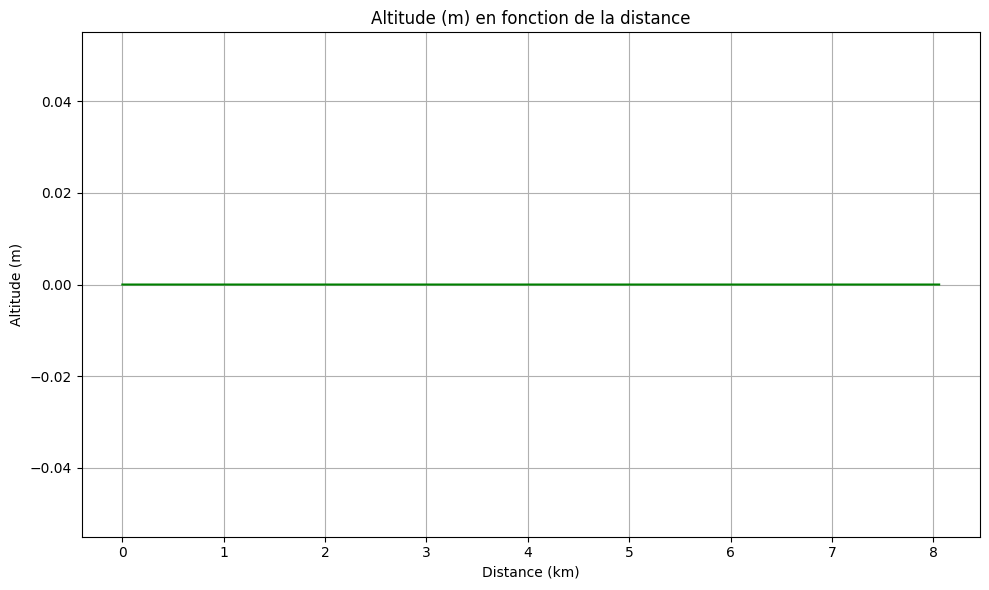

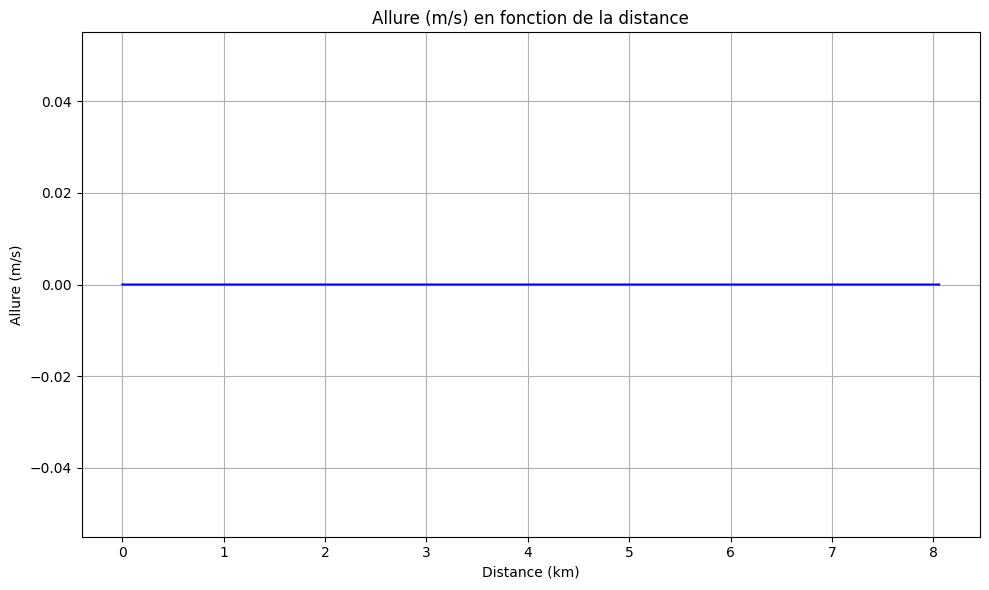

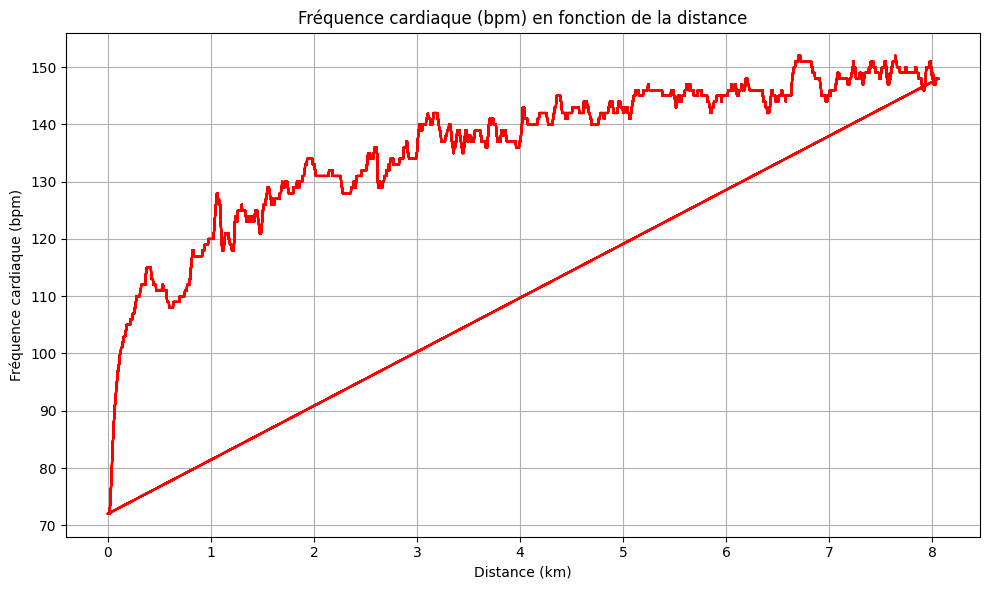

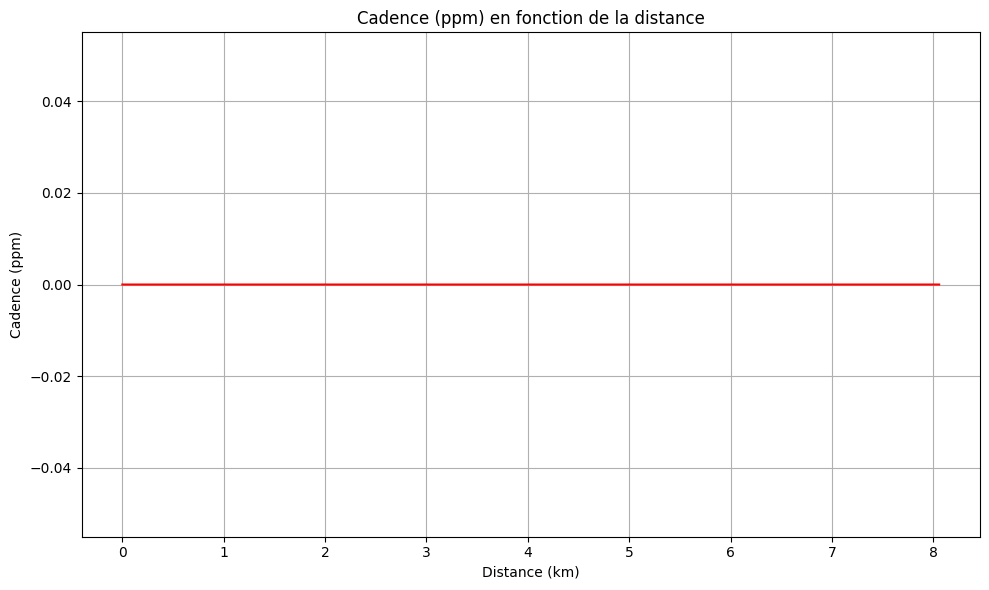

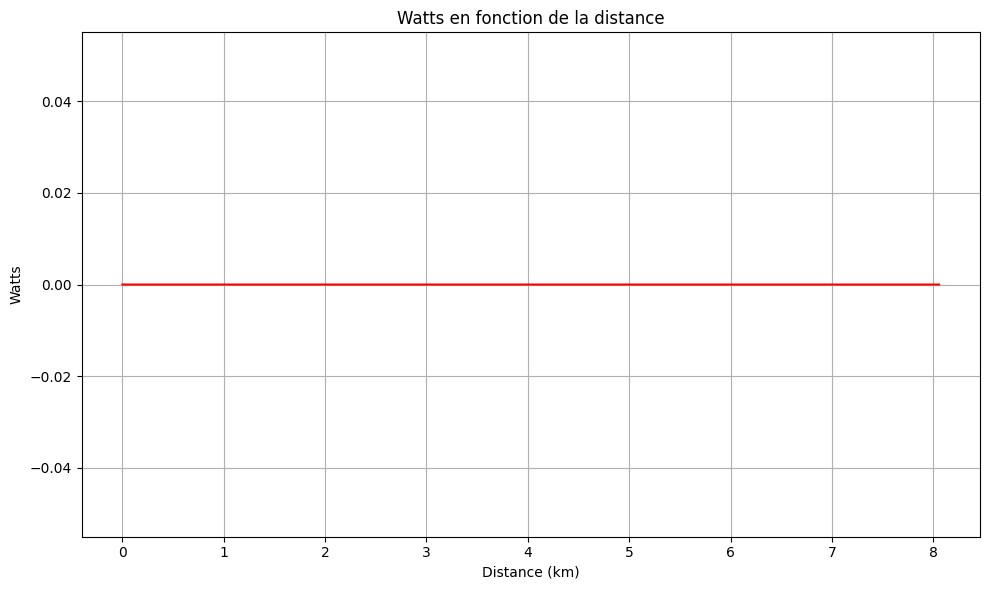

In [ ]:
# Fusionner tous les points GPS de l'activité
activity=all_activities[0]
activity.sport
print(f"Activité : {activity.id}-sport : {activity.sport}")
 
points = [pt for lap in activity.laps for pt in lap.points]


# Pour tracer l'altitude :
plot_data_distance(points, data_name="altitude", ylabel="Altitude (m)", color="green")

# Pour tracer la vitesse :
plot_data_distance(points, data_name="speed", ylabel="Allure (m/s)", color="blue")

# Pour la fréquence cardiaque (si présente) :
plot_data_distance(points, data_name="heartRate", ylabel="Fréquence cardiaque (bpm)", color="red")

# Pour la cadence (si présente) :
plot_data_distance(points, data_name="runCadence", ylabel="Cadence (ppm)", color="red")

# Pour les watts (si présente) :
plot_data_distance(points, data_name="watts", ylabel="Watts", color="red")


In [ ]:
import math
totaldistance=15.02
totaltime=49*60+7
modulospeed1=totaltime % 60 
modulospeed2= (modulospeed1/ totaldistance)*0.6
speedOrPace = math.floor(totaltime / 60 / totaldistance) + modulospeed2

wrongmodulospeed=((totaltime % 60) / totaldistance) * 0.6;
print(f"totaltime : {totaltime} sec")
print(f"Vitesse ou allure : {speedOrPace:.2f} min/km")
print(f"modulo : {modulospeed2:.2f} min/km")
print(f"wrongmodulo : {wrongmodulospeed:.2f} min/km")

totaltime : 2947 sec
Vitesse ou allure : 3.28 min/km
modulo : 0.28 min/km
wrongmodulo : 0.28 min/km


In [ ]:
totalDistance=9.14
totalDuration=54*60+42
print(f"totalDuration : {totalDuration} sec")
print(f"totalDistance : {totalDistance} km")
pacePerKm = totalDuration / totalDistance #Temps en secondes par km
print(f"pacePerKm : {pacePerKm} sec/km")  
minutesPerKm = math.floor(pacePerKm / 60) #Minutes par km
print(f"minutesPerKm : {minutesPerKm} min/km")
secondsPerKm = pacePerKm % 60; #Secondes par km
print(f"secondsPerKm : {secondsPerKm} sec/km")
totalMinutesPerKm = minutesPerKm + secondsPerKm / 60 #Convertir les secondes en fraction de minute
print(totalMinutesPerKm)

totalDuration : 3282 sec
totalDistance : 9.14 km
pacePerKm : 359.0809628008752 sec/km
minutesPerKm : 5 min/km
secondsPerKm : 59.08096280087523 sec/km
5.984682713347921


In [ ]:
totalDistance=9.14
totalDuration=54*60+42
print(f"totalDuration : {totalDuration} sec")
print(f"totalDistance : {totalDistance} km")
pacePerKm = totalDuration / totalDistance #Temps en secondes par km
print(f"pacePerKm : {pacePerKm} sec/km")  
minutesPerKm = math.floor(pacePerKm / 60) #Minutes par km
print(f"minutesPerKm : {minutesPerKm} min/km")
secondsPerKm = pacePerKm % 60; #Secondes par km
print(f"secondsPerKm : {secondsPerKm} sec/km")
print(f"secondsPerKm : {secondsPerKm*0.6} sec/km*0.6")
totalMinutesPerKm = minutesPerKm + (secondsPerKm *0.6/100) #Convertir les secondes en fraction de minute
print(totalMinutesPerKm)

totalDuration : 3282 sec
totalDistance : 9.14 km
pacePerKm : 359.0809628008752 sec/km
minutesPerKm : 5 min/km
secondsPerKm : 59.08096280087523 sec/km
secondsPerKm : 35.44857768052513 sec/km*0.6
5.354485776805252


In [ ]:
import matplotlib.pyplot as plt
from lxml import etree

def plot_data(file):
    ns = {"tcx": "http://www.garmin.com/xmlschemas/TrainingCenterDatabase/v2"}

    tree = etree.parse(file)
    root = tree.getroot()

    distances = []
    altitudes = []
    heart_rates = []

    for tp in root.findall(".//tcx:Trackpoint", namespaces=ns):
        dist_el = tp.find("tcx:DistanceMeters", namespaces=ns)
        alt_el = tp.find("tcx:AltitudeMeters", namespaces=ns)
        hr_el = tp.find("tcx:HeartRateBpm/tcx:Value", namespaces=ns)

        try:
            distances.append(float(dist_el.text) if dist_el is not None else None)
            altitudes.append(float(alt_el.text) if alt_el is not None else None)
            heart_rates.append(int(hr_el.text) if hr_el is not None else None)
        except ValueError:
            # Donnée corrompue ou absente
            distances.append(None)
            altitudes.append(None)
            heart_rates.append(None)

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.set_xlabel("Distance (m)")
    ax1.set_ylabel("Altitude (m)", color="tab:blue")
    ax1.plot(distances, altitudes, color="tab:blue", label="Altitude")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    ax2 = ax1.twinx()
    ax2.set_ylabel("Fréquence cardiaque (bpm)", color="tab:red")
    ax2.plot(distances, heart_rates, color="tab:red", alpha=0.6, label="FC")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Altitude et FC en fonction de la distance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


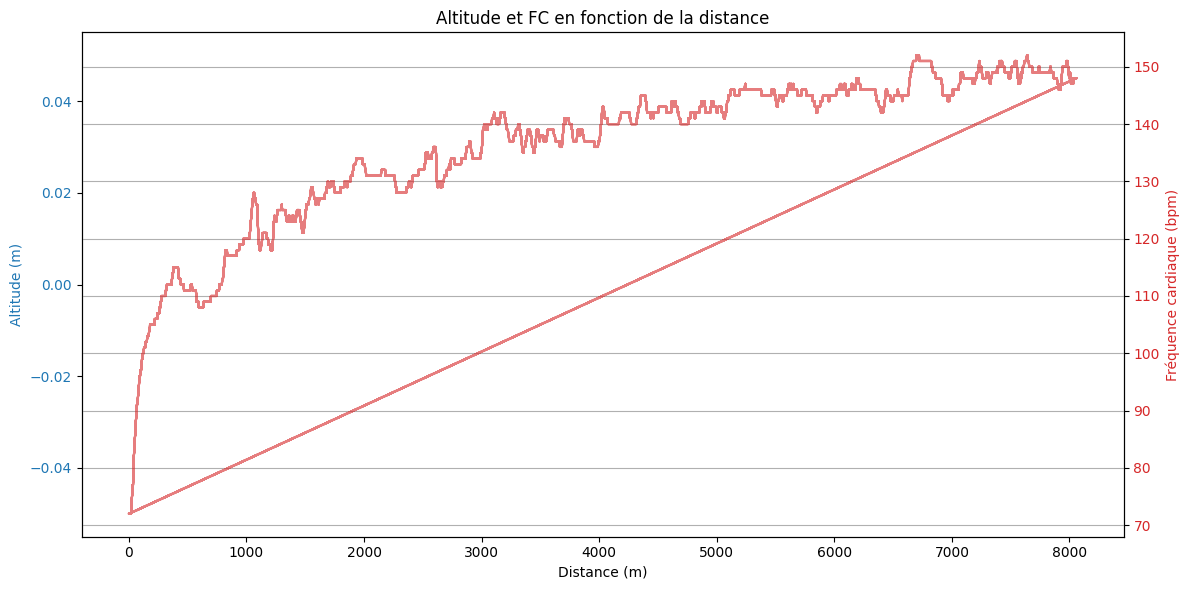

In [ ]:
file_name = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-23-12-13-46.tcx"
plot_data(file_name)


In [ ]:
import matplotlib.pyplot as plt
from lxml import etree

def plot_map_GPX(file):
    ns = {"tcx": "http://www.garmin.com/xmlschemas/TrainingCenterDatabase/v2"}

    tree = etree.parse(file)
    root = tree.getroot()

    latitudes = []
    longitudes = []

    for tp in root.findall(".//tcx:Trackpoint", namespaces=ns):
        pos = tp.find("tcx:Position", namespaces=ns)
        if pos is not None:
            lat_el = pos.find("tcx:LatitudeDegrees", namespaces=ns)
            lon_el = pos.find("tcx:LongitudeDegrees", namespaces=ns)
            if lat_el is not None and lon_el is not None:
                try:
                    latitudes.append(float(lat_el.text))
                    longitudes.append(float(lon_el.text))
                except ValueError:
                    continue

    if not latitudes or not longitudes:
        print("⚠️ Aucune coordonnée trouvée dans le fichier.")
        return

    plt.figure(figsize=(8, 8))
    plt.plot(longitudes, latitudes, marker='o', markersize=2, linewidth=1)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Trace GPS – {file}")
    plt.grid(True)
    plt.axis("equal")
    plt.show()
    


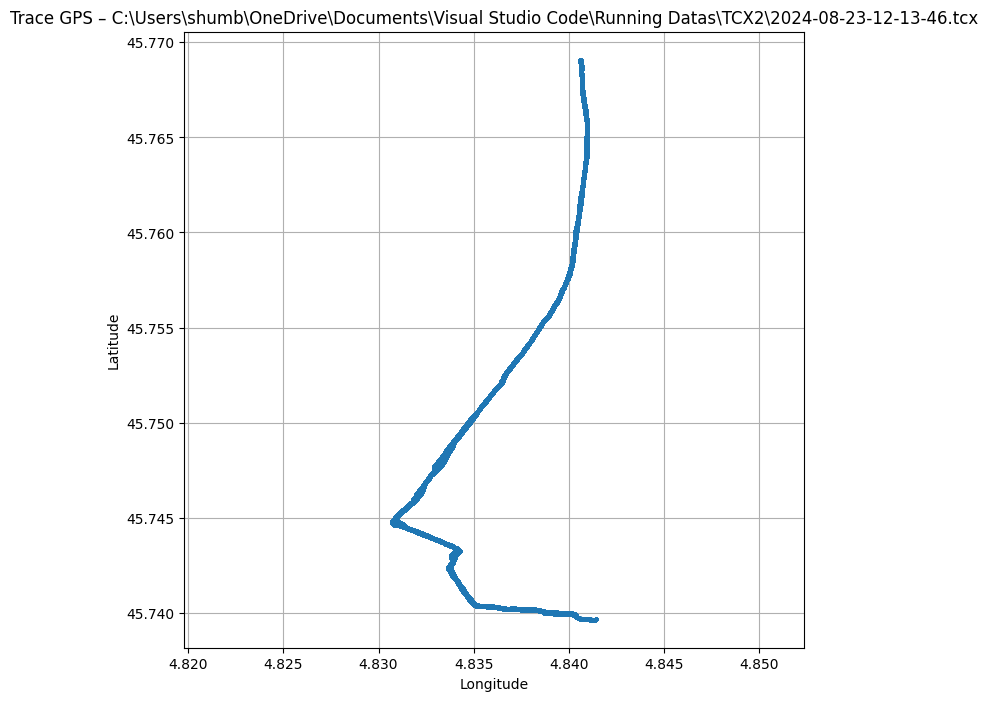

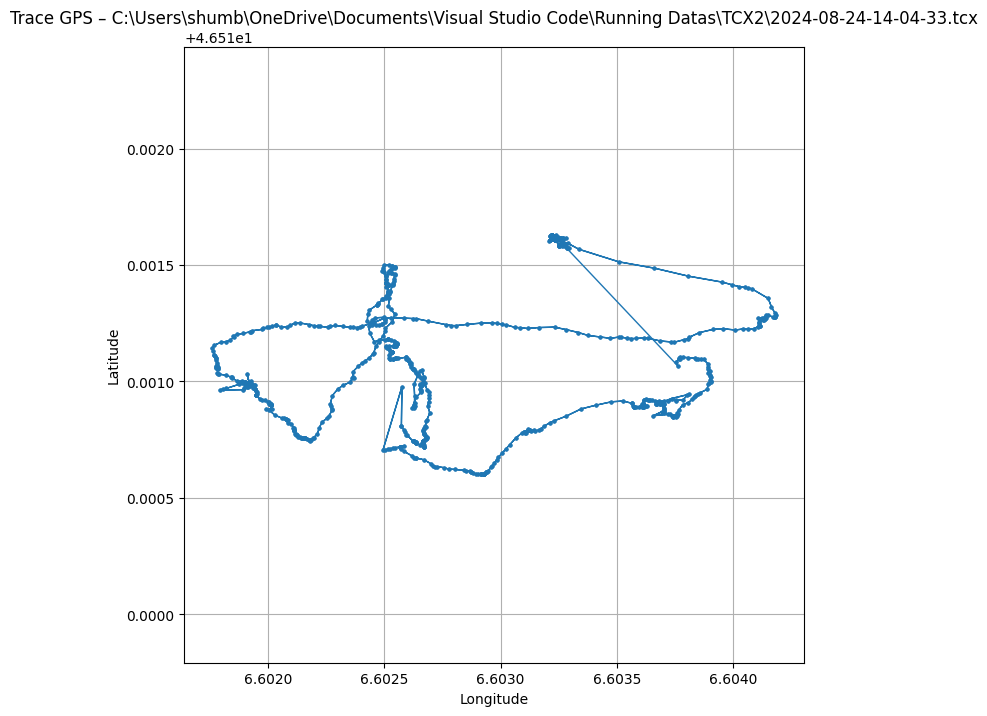

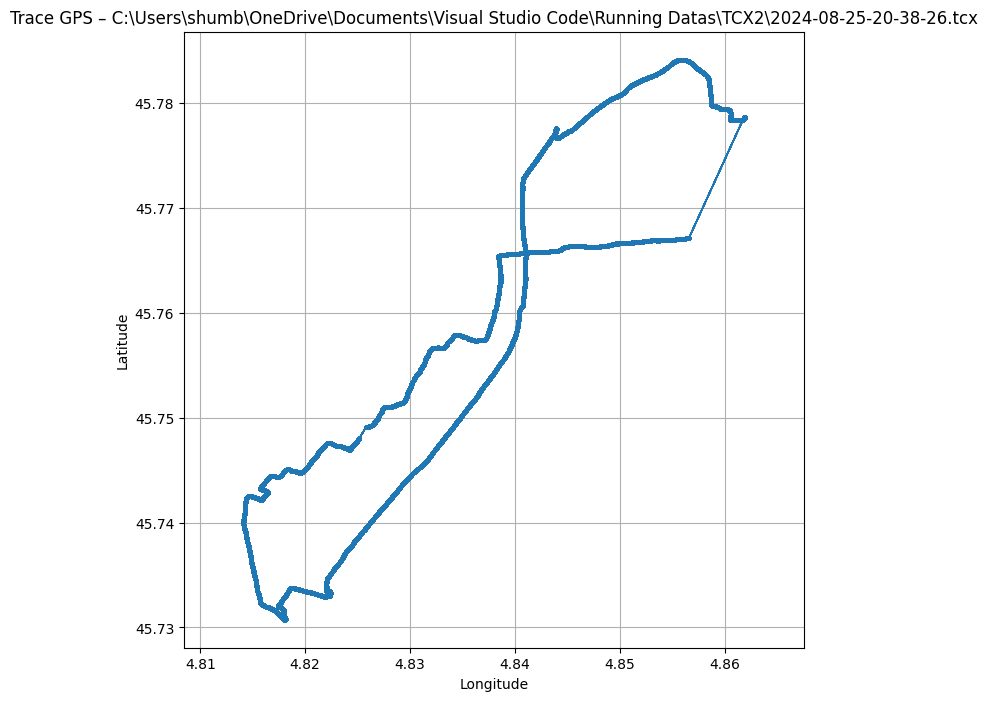

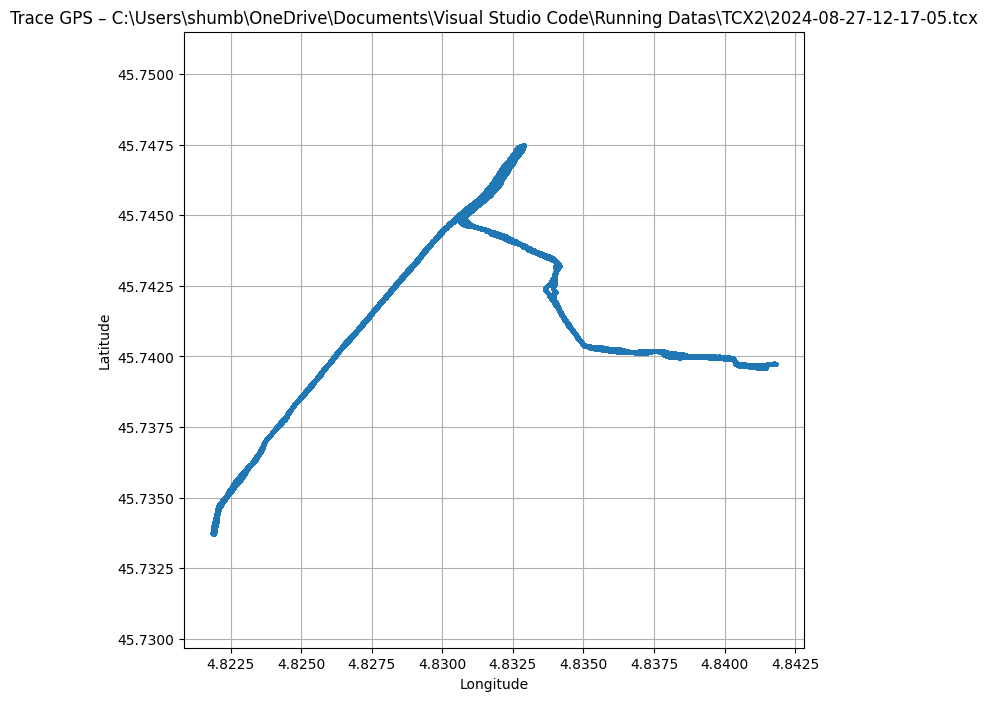

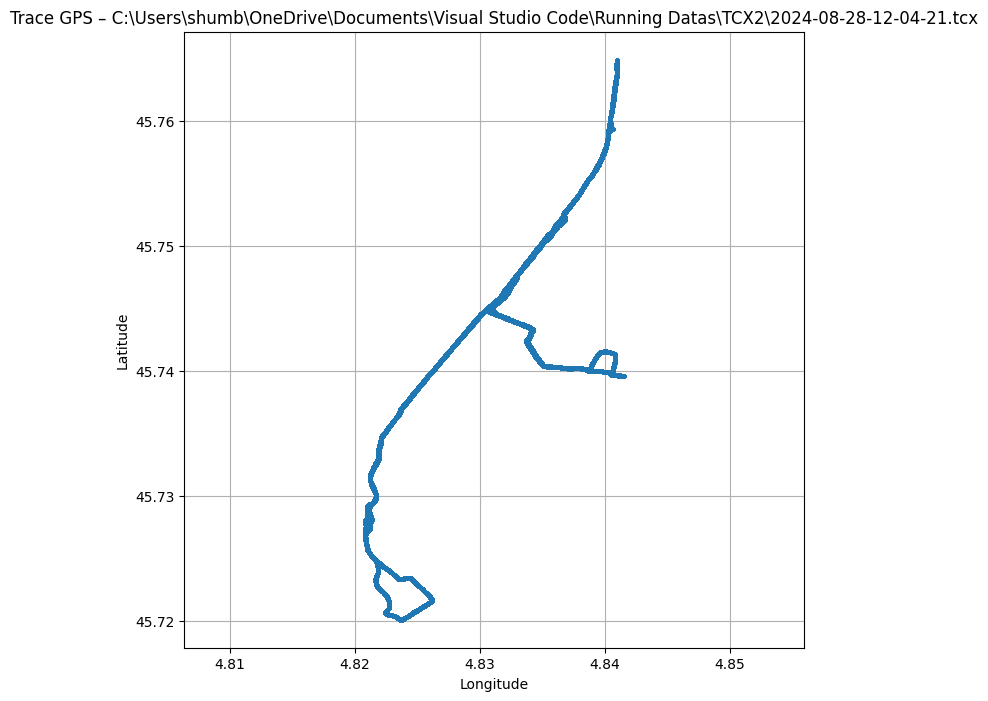

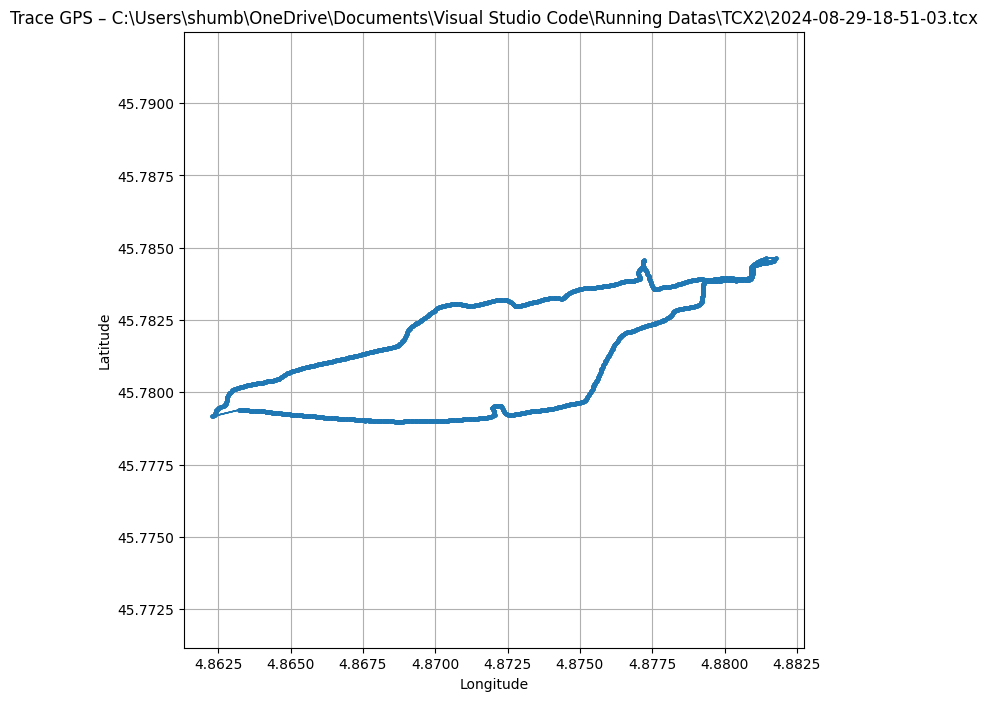

⚠️ Aucune coordonnée trouvée dans le fichier.


In [ ]:
file1 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-23-12-13-46.tcx"
file2 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\\2024-08-24-14-04-33.tcx"
file3 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-25-20-38-26.tcx"
file4 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-27-12-17-05.tcx"
file5 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-28-12-04-21.tcx"
file6 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-29-18-51-03.tcx"
file7 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\TCX2\\2024-08-30-13-22-52.tcx"

plot_map_GPX(file1)
plot_map_GPX(file2)
plot_map_GPX(file3)
plot_map_GPX(file4)
plot_map_GPX(file5)
plot_map_GPX(file6)
plot_map_GPX(file7)


In [ ]:
import matplotlib.pyplot as plt
import json
import os

def plot_map_JSON(file):
    with open(file, 'r', encoding='utf-8') as f:
        data = json.load(f)

    latitudes = []
    longitudes = []

    for lap in data.get("laps", []):
        for pt in lap.get("points", []):
            lat = pt.get("latitude")
            lon = pt.get("longitude")

            # ✅ filtre anti-valeurs aberrantes
            if (
                lat is not None and lon is not None and
                isinstance(lat, (int, float)) and isinstance(lon, (int, float)) and
                -90 <= lat <= 90 and -180 <= lon <= 180 and
                lat != 0.0 and lon != 0.0
            ):
                latitudes.append(lat)
                longitudes.append(lon)

    if not latitudes or not longitudes:
        print("⚠️ Aucune coordonnée valide trouvée dans le fichier JSON.")
        return

    filename = os.path.basename(file)

    plt.figure(figsize=(8, 8))
    plt.plot(longitudes, latitudes, marker='o', markersize=2, linewidth=1)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Trace GPS – {filename}")
    plt.grid(True)
    plt.axis("equal")
    plt.show()


In [ ]:
file1 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-23-12-13-46.json"
file2 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-24-14-04-33.json"
file3 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-25-20-38-26.json"
file4 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-27-12-17-05.json"
file5 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-28-12-04-21.json"
file6 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-29-18-51-03.json"
file7 = "C:\\Users\\shumb\\OneDrive\\Documents\\Visual Studio Code\\Running Datas\\site\\activities_json\\2024-08-30-13-22-52.json"

plot_map_JSON(file1)
plot_map_JSON(file2)
plot_map_JSON(file3)
plot_map_JSON(file4)
plot_map_JSON(file5)
plot_map_JSON(file6)
plot_map_JSON(file7)

NameError: name 'plot_map_JSON' is not defined